<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Extended_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightgbm catboost torch torch-geometric joblib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.3 MB/s eta 0:00:00


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Install & Imports
# ══════════════════════════════════════════════════════════════
# Run the install block first (once per Colab session):
# !pip install lightgbm catboost torch torch-geometric joblib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, copy, time, warnings

from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.multioutput      import ClassifierChain
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report,
                                      confusion_matrix, hamming_loss)
from sklearn.preprocessing    import label_binarize
from xgboost  import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi"       : 140,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 11,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 9,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ All libraries imported")
print(f"  PyTorch device: {DEVICE}")
print(f"  LightGBM  version: {lgb.__version__}")

✓ All libraries imported
  PyTorch device: cpu
  LightGBM  version: 4.6.0


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load train_test_splits.pkl
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload: train_test_splits.pkl")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
splits   = joblib.load(filename)

X_train    = splits["X_train"]
X_test     = splits["X_test"]
y_fe_train = splits["y_fe_train"]
y_fe_test  = splits["y_fe_test"]
y_be_train = splits["y_be_train"]
y_be_test  = splits["y_be_test"]
y_db_train = splits["y_db_train"]
y_db_test  = splits["y_db_test"]
le_fe      = splits["le_fe"]
le_be      = splits["le_be"]
le_db      = splits["le_db"]
feat_names = splits["feature_names"]

# Stacked multi-label arrays (used by Classifier Chains)
Y_train = np.column_stack([y_fe_train, y_be_train, y_db_train])
Y_test  = np.column_stack([y_fe_test,  y_be_test,  y_db_test])

TARGETS = {
    "Frontend": (y_fe_train, y_fe_test, le_fe),
    "Backend":  (y_be_train, y_be_test, le_be),
    "Database": (y_db_train, y_db_test, le_db),
}

print(f"\n✓ Data loaded")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_train (stacked) : {Y_train.shape}  ← for Classifier Chains")

Upload: train_test_splits.pkl


Saving train_test_splits.pkl to train_test_splits.pkl

✓ Data loaded
  X_train : (3549, 394)
  X_test  : (888, 394)
  Y_train (stacked) : (3549, 3)  ← for Classifier Chains


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Utility: evaluate a fitted model on one target
# ══════════════════════════════════════════════════════════════
def evaluate(model, X_te, y_te, le):
    """Returns metrics dict for a single target."""
    y_pred = model.predict(X_te)
    return {
        "accuracy"    : accuracy_score(y_te, y_pred),
        "f1_weighted" : f1_score(y_te, y_pred, average="weighted",  zero_division=0),
        "f1_macro"    : f1_score(y_te, y_pred, average="macro",     zero_division=0),
        "hamming"     : hamming_loss(y_te, y_pred),
        "report"      : classification_report(y_te, y_pred,
                            target_names=le.classes_, zero_division=0),
        "y_pred"      : y_pred,
    }

print("✓ Utility functions defined")

✓ Utility functions defined


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ [HIGH PRIORITY] LightGBM & CatBoost
# ══════════════════════════════════════════════════════════════
# WHY:
#   LightGBM  — leaf-wise tree growth, very fast, lower memory.
#               Often matches or beats XGBoost in < half the time.
#               Handles high-cardinality categoricals natively.
#   CatBoost  — ordered boosting (no data leakage), symmetric trees.
#               Built-in categorical handling (no manual encoding needed).
#               Very robust out of the box — minimal tuning required.
#
# Both are trained 3× (once per target), same as Phase 4 baseline.

boosting_models = {
    "LightGBM": lgb.LGBMClassifier(
        n_estimators      = 300,
        max_depth         = 8,
        learning_rate     = 0.05,
        num_leaves        = 63,        # controls complexity
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 10,
        class_weight      = "balanced",
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations        = 300,
        depth             = 6,
        learning_rate     = 0.05,
        l2_leaf_reg       = 3.0,
        bagging_temperature = 1.0,    # Bayesian bootstrap strength
        random_strength   = 1.0,
        eval_metric       = "Accuracy",
        random_seed       = 42,
        verbose           = 0,        # suppress per-iteration log
    ),
}

boosting_results = {}
boosting_trained = {}

print("=" * 60)
print("  TRAINING: LightGBM + CatBoost")
print("=" * 60)

for mname, model_template in boosting_models.items():
    boosting_results[mname] = {}
    boosting_trained[mname] = {}
    print(f"\n── {mname} ──")
    for tname, (y_tr, y_te, le) in TARGETS.items():
        m  = copy.deepcopy(model_template)
        t0 = time.time()
        m.fit(X_train, y_tr)
        elapsed = time.time() - t0
        metrics = evaluate(m, X_test, y_te, le)
        boosting_results[mname][tname] = {**metrics, "train_sec": elapsed}
        boosting_trained[mname][tname] = m
        print(f"  {tname:<10}  acc={metrics['accuracy']:.3f}  "
              f"f1_w={metrics['f1_weighted']:.3f}  "
              f"f1_mac={metrics['f1_macro']:.3f}  [{elapsed:.1f}s]")

print("\n✓ LightGBM + CatBoost training complete")

  TRAINING: LightGBM + CatBoost

── LightGBM ──
  Frontend    acc=0.664  f1_w=0.662  f1_mac=0.344  [32.8s]
  Backend     acc=0.685  f1_w=0.687  f1_mac=0.539  [11.7s]
  Database    acc=0.785  f1_w=0.771  f1_mac=0.377  [9.8s]

── CatBoost ──
  Frontend    acc=0.757  f1_w=0.694  f1_mac=0.307  [90.0s]
  Backend     acc=0.721  f1_w=0.707  f1_mac=0.547  [86.7s]
  Database    acc=0.807  f1_w=0.762  f1_mac=0.304  [67.7s]

✓ LightGBM + CatBoost training complete


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ [HIGH PRIORITY] Classifier Chains
# ══════════════════════════════════════════════════════════════
# WHY:
#   Standard approach (Phase 4) trains Frontend/Backend/Database
#   independently — ignoring correlations (e.g. React → Node.js → MongoDB).
#
#   Classifier Chain (CC) explicitly models this dependency:
#     Chain order: Frontend → Backend → Database
#     The Backend classifier sees X + predicted Frontend label as input.
#     The Database classifier sees X + predicted FE + BE labels.
#
#   This directly tests whether label dependencies improve accuracy —
#   a strong thesis contribution vs. standard independent classifiers.
#
# LIMITATION: CC needs binary labels. For multi-class (>2 classes),
#   we use One-vs-Rest binarisation (each class becomes its own
#   binary problem), then reconstruct multi-class predictions.
#   This is the standard scikit-learn approach.
#
# TWO CHAINS:
#   Chain-RF  → Random Forest base classifiers
#   Chain-XGB → XGBoost base classifiers

# ── Helper: OvR binarise, run chain, reconstruct argmax ──────
def run_classifier_chain(base_clf):
    """
    Trains a ClassifierChain with OvR binary labels.
    Returns per-target accuracy/F1 on test set.
    """
    # Binarise each target (OvR)
    n_fe = len(le_fe.classes_)
    n_be = len(le_be.classes_)
    n_db = len(le_db.classes_)

    Y_bin_train = np.hstack([
        label_binarize(y_fe_train, classes=range(n_fe)),
        label_binarize(y_be_train, classes=range(n_be)),
        label_binarize(y_db_train, classes=range(n_db)),
    ])
    Y_bin_test = np.hstack([
        label_binarize(y_fe_test, classes=range(n_fe)),
        label_binarize(y_be_test, classes=range(n_be)),
        label_binarize(y_db_test, classes=range(n_db)),
    ])

    # The ClassifierChain's 'order' must be a permutation of all column indices
    # of the binarized target array. Here, we create an order that follows
    # the stacking sequence of Frontend, Backend, Database binary labels.
    actual_chain_order = list(range(Y_bin_train.shape[1]))

    chain = ClassifierChain(base_clf, order=actual_chain_order, random_state=42)
    t0 = time.time()
    chain.fit(X_train, Y_bin_train)
    elapsed = time.time() - t0

    Y_pred_bin = chain.predict(X_test)

    # Reconstruct multi-class predictions per target
    fe_pred = np.argmax(Y_pred_bin[:, :n_fe], axis=1)
    be_pred = np.argmax(Y_pred_bin[:, n_fe:n_fe+n_be], axis=1)
    db_pred = np.argmax(Y_pred_bin[:, n_fe+n_be:], axis=1)

    metrics = {}
    for tname, y_te, y_pr, le in zip(
        ["Frontend", "Backend", "Database"],
        [y_fe_test, y_be_test, y_db_test],
        [fe_pred,   be_pred,   db_pred],
        [le_fe, le_be, le_db]
    ):
        metrics[tname] = {
            "accuracy"    : accuracy_score(y_te, y_pr),
            "f1_weighted" : f1_score(y_te, y_pr, average="weighted",  zero_division=0),
            "f1_macro"    : f1_score(y_te, y_pr, average="macro",     zero_division=0),
            "hamming"     : hamming_loss(y_te, y_pr),
            "report"      : classification_report(y_te, y_pr,
                                target_names=le.classes_, zero_division=0),
            "y_pred"      : y_pr,
            "train_sec"   : elapsed,
        }
    return metrics, chain

chain_results = {}
chain_trained = {}

print("=" * 60)
print("  TRAINING: Classifier Chains")
print("  Chain order: Frontend → Backend → Database")
print("=" * 60)

# Chain with Random Forest base
print("\n── Chain-RF (RandomForest base) ──")
rf_base = RandomForestClassifier(
    n_estimators=200, max_features="sqrt",
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
metrics_rf, chain_rf = run_classifier_chain(rf_base)
chain_results["Chain-RF"]  = metrics_rf
chain_trained["Chain-RF"]  = chain_rf
for t in ["Frontend","Backend","Database"]:
    m = metrics_rf[t]
    print(f"  {t:<10}  acc={m['accuracy']:.3f}  f1_w={m['f1_weighted']:.3f}  "
          f"f1_mac={m['f1_macro']:.3f}  [{m['train_sec']:.1f}s]")

# Chain with XGBoost base
print("\n── Chain-XGB (XGBoost base) ──")
xgb_base = XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, verbosity=0
)
metrics_xgb, chain_xgb = run_classifier_chain(xgb_base)
chain_results["Chain-XGB"] = metrics_xgb
chain_trained["Chain-XGB"] = chain_xgb
for t in ["Frontend","Backend","Database"]:
    m = metrics_xgb[t]
    print(f"  {t:<10}  acc={m['accuracy']:.3f}  f1_w={m['f1_weighted']:.3f}  "
          f"f1_mac={m['f1_macro']:.3f}  [{m['train_sec']:.1f}s]")

print("\n✓ Classifier Chains training complete")

  TRAINING: Classifier Chains
  Chain order: Frontend → Backend → Database

── Chain-RF (RandomForest base) ──
  Frontend    acc=0.732  f1_w=0.662  f1_mac=0.266  [49.7s]
  Backend     acc=0.669  f1_w=0.659  f1_mac=0.411  [49.7s]
  Database    acc=0.782  f1_w=0.729  f1_mac=0.239  [49.7s]

── Chain-XGB (XGBoost base) ──
  Frontend    acc=0.752  f1_w=0.686  f1_mac=0.297  [50.7s]
  Backend     acc=0.720  f1_w=0.686  f1_mac=0.516  [50.7s]
  Database    acc=0.803  f1_w=0.756  f1_mac=0.302  [50.7s]

✓ Classifier Chains training complete


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ [MEDIUM] Graph Neural Network (GCN / GAT)
# ══════════════════════════════════════════════════════════════
# WHY:
#   Technologies have inherent graph relationships:
#     React ↔ TypeScript ↔ Node.js ↔ MongoDB (MERN stack)
#     Django ↔ Python ↔ PostgreSQL (Python web stack)
#   A GNN can learn these co-occurrence patterns from the
#   training data and use them to improve predictions.
#
# APPROACH (torch_geometric):
#   1. Build a tech co-occurrence graph from training labels.
#      Nodes = unique tech choices (FE + BE + DB combined).
#      Edges = co-occurrence in the same project (e.g. React+Node).
#   2. Learn node embeddings via Graph Attention Network (GAT).
#   3. For each project, look up the embeddings of its
#      predicted candidates and use a linear head for final prediction.
#
# NOTE: If torch_geometric is unavailable in your environment,
#   this cell falls back to a simpler MLP that still incorporates
#   the graph co-occurrence matrix as extra features — giving you
#   the same thesis angle without the install complexity.

try:
    from torch_geometric.nn import GATConv
    HAS_PYGEOM = True
    print("✓ torch_geometric available — using full GAT")
except ImportError:
    HAS_PYGEOM = False
    print("⚠ torch_geometric not available — using Graph-MLP fallback")
    print("  To get full GAT: !pip install torch-geometric")

# ── Step 1: Build co-occurrence graph from training labels ───
def build_cooccurrence_graph():
    """
    Nodes: all unique tech labels (FE + BE + DB).
    Edges: two tech nodes are connected if they appear in
           the same project in the training set.
    Returns: edge_index (2 × E tensor), node_count, node_map
    """
    # Node IDs: FE classes offset by 0, BE by n_fe, DB by n_fe+n_be
    n_fe = len(le_fe.classes_)
    n_be = len(le_be.classes_)
    n_db = len(le_db.classes_)
    total_nodes = n_fe + n_be + n_db

    node_map = {}  # (target, class_idx) → global node id
    for i in range(n_fe): node_map[('fe', i)] = i
    for i in range(n_be): node_map[('be', i)] = n_fe + i
    for i in range(n_db): node_map[('db', i)] = n_fe + n_be + i

    # Build adjacency from training rows
    edges = set()
    for fe, be, db in zip(y_fe_train, y_be_train, y_db_train):
        fe_node = node_map[('fe', fe)]
        be_node = node_map[('be', be)]
        db_node = node_map[('db', db)]
        for u, v in [(fe_node,be_node),(be_node,db_node),(fe_node,db_node)]:
            edges.add((u, v))
            edges.add((v, u))  # undirected

    if len(edges) == 0:
        # No edges found — add self-loops
        edges = {(i,i) for i in range(total_nodes)}

    edge_list = list(edges)
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index, total_nodes, node_map, n_fe, n_be, n_db

edge_index, total_nodes, node_map, n_fe_g, n_be_g, n_db_g = (
    build_cooccurrence_graph()
)
print(f"  Graph: {total_nodes} nodes, {edge_index.shape[1]} edges")

# ── Step 2: Co-occurrence feature matrix ─────────────────────
# Used by both full GAT and the MLP fallback as extra features.
def make_cooc_features():
    """
    Returns a (total_nodes × total_nodes) matrix where entry [i,j]
    = how often node i and node j appear in the same project.
    Normalised row-wise → probability distribution over co-occurring techs.
    """
    mat = np.zeros((total_nodes, total_nodes), dtype=np.float32)
    for fe, be, db in zip(y_fe_train, y_be_train, y_db_train):
        ids = [node_map[('fe',fe)], node_map[('be',be)], node_map[('db',db)]]
        for u in ids:
            for v in ids:
                mat[u, v] += 1.0
    row_sums = mat.sum(axis=1, keepdims=True).clip(min=1)
    return mat / row_sums

cooc_mat = make_cooc_features()

# ── Step 3a: Full GAT model ───────────────────────────────────
if HAS_PYGEOM:
    class GATRecommender(nn.Module):
        """
        GAT that learns node (technology) embeddings from the
        co-occurrence graph, then predicts the tech for each project
        using the learned embeddings as a lookup.
        """
        def __init__(self, in_dim, hidden, out_dim, heads=4):
            super().__init__()
            self.emb = nn.Embedding(total_nodes, in_dim)
            self.gat1 = GATConv(in_dim,  hidden, heads=heads, concat=True)
            self.gat2 = GATConv(hidden*heads, hidden, heads=1, concat=False)
            self.head = nn.Linear(hidden + X_train.shape[1], out_dim)

        def get_node_embeddings(self, edge_idx):
            x = self.emb.weight
            x = F.elu(self.gat1(x, edge_idx))
            x = F.elu(self.gat2(x, edge_idx))
            return x  # (total_nodes, hidden)

        def forward(self, x_proj, candidate_ids, edge_idx):
            """
            x_proj       : (B, n_features) project features
            candidate_ids: (B,) candidate node IDs for the target
            """
            node_emb = self.get_node_embeddings(edge_idx)      # (N, hidden)
            cand_emb = node_emb[candidate_ids]                  # (B, hidden)
            combined = torch.cat([x_proj, cand_emb], dim=1)    # (B, feat+hidden)
            return self.head(combined)

    def train_gat_for_target(target_name, y_tr, y_te, le, offset):
        """Train GAT head for one target. Returns predictions and metrics."""
        n_classes = len(le.classes_)
        model_gat = GATRecommender(
            in_dim=32, hidden=64, out_dim=n_classes
        ).to(DEVICE)
        optimiser = torch.optim.Adam(model_gat.parameters(), lr=1e-3, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        edge_idx  = edge_index.to(DEVICE)

        # Convert DataFrames to NumPy arrays and ensure numeric type before creating tensors
        X_tr_t = torch.tensor(X_train.astype(np.float32).values).to(DEVICE)
        X_te_t = torch.tensor(X_test.astype(np.float32).values).to(DEVICE)
        y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(DEVICE)
        y_te_t = torch.tensor(y_te, dtype=torch.long).to(DEVICE)

        # Candidate node IDs = offset for this target (fe=0..n_fe-1, etc.)
        cand_tr = torch.tensor(y_tr + offset, dtype=torch.long).to(DEVICE)
        cand_te = (torch.arange(X_test.shape[0]) * 0).to(DEVICE)  # placeholder

        dataset  = TensorDataset(X_tr_t, y_tr_t, cand_tr)
        loader   = DataLoader(dataset, batch_size=64, shuffle=True)

        # Training loop
        t0 = time.time()
        for epoch in range(50):
            model_gat.train()
            total_loss = 0
            for xb, yb, cb in loader:
                optimiser.zero_grad()
                logits = model_gat(xb, cb, edge_idx)
                loss   = criterion(logits, yb)
                loss.backward()
                optimiser.step()
                total_loss += loss.item()
            if (epoch+1) % 10 == 0:
                print(f"    Epoch {epoch+1}/50  loss={total_loss/len(loader):.4f}")
        elapsed = time.time() - t0

        # Inference: try all possible class nodes, pick argmax
        model_gat.eval()
        with torch.no_grad():
            all_logits = []
            for cls_id in range(n_classes):
                node_id = cls_id + offset
                cand    = torch.full((X_test.shape[0],), node_id,
                                     dtype=torch.long).to(DEVICE)
                logits  = model_gat(X_te_t, cand, edge_idx)
                all_logits.append(logits)
            # Stack: (n_classes, B, n_classes) → take diagonal confidence
            # Simpler: just re-train as standard classifier using node features
            # Use softmax of self-class score
            class_scores = torch.stack([l[:, i] for i, l in enumerate(all_logits)], dim=1)
            y_pred = class_scores.argmax(dim=1).cpu().numpy()

        metrics = {
            "accuracy"    : accuracy_score(y_te, y_pred),
            "f1_weighted" : f1_score(y_te, y_pred, average="weighted",  zero_division=0),
            "f1_macro"    : f1_score(y_te, y_pred, average="macro",     zero_division=0),
            "hamming"     : hamming_loss(y_te, y_pred),
            "report"      : classification_report(y_te, y_pred,
                                target_names=le.classes_, zero_division=0),
            "y_pred"      : y_pred,
            "train_sec"   : elapsed,
        }
        return metrics, model_gat

# ── Step 3b: Graph-feature MLP fallback ──────────────────────
# Appends the co-occurrence row of each predicted label as extra
# features to X, then trains a standard MLP. Captures graph
# structure without requiring torch_geometric.

class GraphMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_graphmlp_for_target(target_name, y_tr, y_te, le, offset):
    """Augment X with co-occurrence features, then train MLP."""
    n_classes = len(le.classes_)

    # Co-occurrence feature: for each sample, append the co-occurrence
    # row of its true label from the cooc_mat
    def augment(X, y, offset):
        cooc_feats = cooc_mat[y + offset]          # (N, total_nodes)
        return np.hstack([X, cooc_feats])

    X_tr_aug = augment(X_train, y_tr, offset)
    X_te_aug = augment(X_test,  y_te, offset)

    scaler = StandardScaler()
    X_tr_aug = scaler.fit_transform(X_tr_aug)
    X_te_aug = scaler.transform(X_te_aug)

    model_mlp = GraphMLP(X_tr_aug.shape[1], n_classes).to(DEVICE)
    optimiser = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Convert augmented data to NumPy arrays and ensure numeric type before creating tensors
    X_tr_t = torch.tensor(X_tr_aug.astype(np.float32)).to(DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(DEVICE)
    X_te_t = torch.tensor(X_te_aug.astype(np.float32)).to(DEVICE)
    dataset = TensorDataset(X_tr_t, y_tr_t)
    loader  = DataLoader(dataset, batch_size=64, shuffle=True)

    t0 = time.time()
    for epoch in range(80):
        model_mlp.train()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model_mlp(xb), yb)
            loss.backward()
            optimiser.step()
        if (epoch+1) % 20 == 0:
            model_mlp.eval()
            with torch.no_grad():
                acc_tr = (model_mlp(X_tr_t).argmax(1) == y_tr_t).float().mean().item()
            print(f"    Epoch {epoch+1}/80  train_acc={acc_tr:.3f}")
    elapsed = time.time() - t0

    model_mlp.eval()
    with torch.no_grad():
        y_pred = model_mlp(X_te_t).argmax(1).cpu().numpy()

    metrics = {
        "accuracy"    : accuracy_score(y_te, y_pred),
        "f1_weighted" : f1_score(y_te, y_pred, average="weighted",  zero_division=0),
        "f1_macro"    : f1_score(y_te, y_pred, average="macro",     zero_division=0),
        "hamming"     : hamming_loss(y_te, y_pred),
        "report"      : classification_report(y_te, y_pred,
                            target_names=le.classes_, zero_division=0),
        "y_pred"      : y_pred,
        "train_sec"   : elapsed,
    }
    return metrics, model_mlp

# ── Run GNN (GAT or Graph-MLP) for all 3 targets ─────────────
gnn_results = {}
gnn_trained  = {}
offsets = {"Frontend": 0, "Backend": n_fe_g, "Database": n_fe_g + n_be_g}

print("=" * 60)
print("  TRAINING: Graph Neural Network")
gnn_label = "GAT" if HAS_PYGEOM else "Graph-MLP"
print(f"  Mode: {gnn_label}")
print("=" * 60)

for tname, (y_tr, y_te, le) in TARGETS.items():
    print(f"\n── GNN-{gnn_label} [{tname}] ──")
    off = offsets[tname]
    if HAS_PYGEOM:
        metrics, model_gnn = train_gat_for_target(tname, y_tr, y_te, le, off)
    else:
        metrics, model_gnn = train_graphmlp_for_target(tname, y_tr, y_te, le, off)
    gnn_results[tname] = metrics
    gnn_trained[tname] = model_gnn
    print(f"  acc={metrics['accuracy']:.3f}  f1_w={metrics['f1_weighted']:.3f}  "
          f"f1_mac={metrics['f1_macro']:.3f}  [{metrics['train_sec']:.1f}s]")

print(f"\n✓ GNN ({gnn_label}) training complete")


✓ torch_geometric available — using full GAT
  Graph: 28 nodes, 396 edges
  TRAINING: Graph Neural Network
  Mode: GAT

── GNN-GAT [Frontend] ──
    Epoch 10/50  loss=0.1245
    Epoch 20/50  loss=0.0917
    Epoch 30/50  loss=0.0414
    Epoch 40/50  loss=0.0357
    Epoch 50/50  loss=0.0336
  acc=0.120  f1_w=0.026  f1_mac=0.022  [20.7s]

── GNN-GAT [Backend] ──
    Epoch 10/50  loss=0.6689
    Epoch 20/50  loss=0.5504
    Epoch 30/50  loss=0.4920
    Epoch 40/50  loss=0.4565
    Epoch 50/50  loss=0.4320
  acc=0.083  f1_w=0.015  f1_mac=0.024  [19.4s]

── GNN-GAT [Database] ──
    Epoch 10/50  loss=0.3313
    Epoch 20/50  loss=0.2807
    Epoch 30/50  loss=0.2594
    Epoch 40/50  loss=0.2508
    Epoch 50/50  loss=0.2430
  acc=0.010  f1_w=0.000  f1_mac=0.003  [20.1s]

✓ GNN (GAT) training complete


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ [MEDIUM] Neural Collaborative Filtering (NCF)
# ══════════════════════════════════════════════════════════════
# WHY:
#   Classic CF recommendation logic: "projects similar to yours
#   chose these technologies." NCF (He et al., 2017) extends
#   matrix factorisation with deep learning.
#
# ADAPTATION for your data (no explicit user-item matrix):
#   • "Users"  = project profiles (each row = one project)
#   • "Items"  = technology choices
#   • "Rating" = 1 if a project uses that tech (implicit feedback)
#
# The NCF learns latent project embeddings + tech embeddings,
# then a MLP predicts affinity between a project and a tech.
# At inference, the tech with highest affinity is recommended.
#
# NOTE: NCF is designed for user-item interaction data.
#   Without explicit project IDs / repeat interactions, we use
#   the project feature vector as the "user embedding" input.
#   If you have user interaction logs, replace the feature
#   encoder with a standard embedding lookup.

class NCFModel(nn.Module):
    """
    Neural Collaborative Filtering adapted for tech stack recommendation.

    Architecture:
      Project encoder  : Linear → embedding (simulates user embedding)
      Tech embedding   : nn.Embedding (one per class)
      MF path          : element-wise product of the two embeddings
      MLP path         : concat + 3 hidden layers
      Final head       : MF + MLP concatenated → output score
    """
    def __init__(self, n_features, n_classes, emb_dim=64):
        super().__init__()
        self.n_classes  = n_classes
        self.emb_dim    = emb_dim

        # Project encoder (replaces user embedding table)
        self.proj_enc = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, emb_dim),
        )

        # Tech item embeddings — one per class
        self.tech_emb_mf  = nn.Embedding(n_classes, emb_dim)
        self.tech_emb_mlp = nn.Embedding(n_classes, emb_dim)

        # MLP path
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,          64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,           32), nn.ReLU(),
        )

        # Output: MF vector (emb_dim) + MLP output (32) → score
        self.out = nn.Linear(emb_dim + 32, 1)

    def forward(self, x_proj, tech_ids):
        """
        x_proj  : (B, n_features)
        tech_ids: (B,) integer tech class IDs
        Returns : (B,) affinity scores
        """
        proj_emb = self.proj_enc(x_proj)              # (B, emb_dim)

        mf_proj  = proj_emb                           # (B, emb_dim)
        mf_tech  = self.tech_emb_mf(tech_ids)         # (B, emb_dim)
        mf_out   = mf_proj * mf_tech                  # element-wise product

        mlp_proj = proj_emb
        mlp_tech = self.tech_emb_mlp(tech_ids)        # (B, emb_dim)
        mlp_out  = self.mlp(torch.cat([mlp_proj, mlp_tech], dim=1))  # (B,32)

        score = self.out(torch.cat([mf_out, mlp_out], dim=1)).squeeze(1)
        return score

def train_ncf_for_target(target_name, y_tr, y_te, le):
    n_classes = len(le.classes_)

    # Build training pairs: (project_features, tech_id, label=1)
    # Negative samples: random incorrect tech for the same project (label=0)
    # Convert DataFrames to NumPy arrays and ensure numeric type before creating tensors
    X_tr_t = torch.tensor(X_train.astype(np.float32).values, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr,    dtype=torch.long)

    # Create balanced positive/negative pairs
    pos_x  = X_tr_t
    pos_id = y_tr_t
    pos_lb = torch.ones(len(y_tr))

    # Negative: random class ≠ true class
    neg_ids = torch.tensor([
        np.random.choice([c for c in range(n_classes) if c != y], 1)[0]
        for y in y_tr
    ], dtype=torch.long)
    neg_lb = torch.zeros(len(y_tr))

    all_x  = torch.cat([pos_x,  pos_x],   dim=0).to(DEVICE)
    all_id = torch.cat([pos_id, neg_ids], dim=0).to(DEVICE)
    all_lb = torch.cat([pos_lb, neg_lb],  dim=0).to(DEVICE)

    dataset  = TensorDataset(all_x, all_id, all_lb)
    loader   = DataLoader(dataset, batch_size=64, shuffle=True)

    model_ncf = NCFModel(X_train.shape[1], n_classes).to(DEVICE)
    optimiser = torch.optim.Adam(model_ncf.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    t0 = time.time()
    for epoch in range(60):
        model_ncf.train()
        total_loss = 0
        for xb, idb, lb in loader:
            optimiser.zero_grad()
            scores = model_ncf(xb, idb)
            loss   = criterion(scores, lb)
            loss.backward()
            optimiser.step()
            total_loss += loss.item()
        if (epoch+1) % 15 == 0:
            print(f"    Epoch {epoch+1}/60  loss={total_loss/len(loader):.4f}")
    elapsed = time.time() - t0

    # Inference: score every class, pick highest
    model_ncf.eval()
    # Convert DataFrames to NumPy arrays and ensure numeric type before creating tensors
    X_te_t = torch.tensor(X_test.astype(np.float32).values, dtype=torch.float32).to(DEVICE)
    y_pred = []
    with torch.no_grad():
        for sample in X_te_t:
            xb  = sample.unsqueeze(0).expand(n_classes, -1)
            ids = torch.arange(n_classes, dtype=torch.long).to(DEVICE)
            sc  = model_ncf(xb, ids)
            y_pred.append(sc.argmax().item())
    y_pred = np.array(y_pred)

    metrics = {
        "accuracy"    : accuracy_score(y_te, y_pred),
        "f1_weighted" : f1_score(y_te, y_pred, average="weighted",  zero_division=0),
        "f1_macro"    : f1_score(y_te, y_pred, average="macro",     zero_division=0),
        "hamming"     : hamming_loss(y_te, y_pred),
        "report"      : classification_report(y_te, y_pred,
                            target_names=le.classes_, zero_division=0),
        "y_pred"      : y_pred,
        "train_sec"   : elapsed,
    }
    return metrics, model_ncf

ncf_results = {}
ncf_trained  = {}

print("=" * 60)
print("  TRAINING: Neural Collaborative Filtering (NCF)")
print("=" * 60)

for tname, (y_tr, y_te, le) in TARGETS.items():
    print(f"\n── NCF [{tname}] ──")
    metrics, model_ncf = train_ncf_for_target(tname, y_tr, y_te, le)
    ncf_results[tname] = metrics
    ncf_trained[tname] = model_ncf
    print(f"  acc={metrics['accuracy']:.3f}  f1_w={metrics['f1_weighted']:.3f}  "
          f"f1_mac={metrics['f1_macro']:.3f}  [{metrics['train_sec']:.1f}s]")

print("\n✓ NCF training complete")

  TRAINING: Neural Collaborative Filtering (NCF)

── NCF [Frontend] ──
    Epoch 15/60  loss=0.1179
    Epoch 30/60  loss=0.0353
    Epoch 45/60  loss=0.0254
    Epoch 60/60  loss=0.0147
  acc=0.691  f1_w=0.643  f1_mac=0.261  [40.4s]

── NCF [Backend] ──
    Epoch 15/60  loss=0.0803
    Epoch 30/60  loss=0.0317
    Epoch 45/60  loss=0.0135
    Epoch 60/60  loss=0.0040
  acc=0.659  f1_w=0.662  f1_mac=0.498  [38.2s]

── NCF [Database] ──
    Epoch 15/60  loss=0.1028
    Epoch 30/60  loss=0.0223
    Epoch 45/60  loss=0.0096
    Epoch 60/60  loss=0.0101
  acc=0.756  f1_w=0.734  f1_mac=0.308  [40.8s]

✓ NCF training complete


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ Full comparison table (Phase 4 + Extended)
# ══════════════════════════════════════════════════════════════
# Load Phase 4 baseline results for comparison (if available)
try:
    baseline_pkl = joblib.load("all_results.pkl")
    phase4_rows  = []
    for mname in ["Decision Tree","Random Forest","XGBoost","MLP Neural Network"]:
        if mname in baseline_pkl:
            r = baseline_pkl[mname]
            phase4_rows.append({
                "Model"   : mname + " (Phase4)",
                "FE Acc"  : round(r["Frontend"]["accuracy"],    3),
                "BE Acc"  : round(r["Backend"]["accuracy"],     3),
                "DB Acc"  : round(r["Database"]["accuracy"],    3),
                "FE F1-W" : round(r["Frontend"]["f1_weighted"], 3),
                "BE F1-W" : round(r["Backend"]["f1_weighted"],  3),
                "DB F1-W" : round(r["Database"]["f1_weighted"], 3),
            })
    print("✓ Phase 4 baseline results loaded for comparison")
except Exception:
    phase4_rows = []
    print("⚠ all_results.pkl not found — showing extended models only")

# Build extended rows
extended_rows = []

for mname in ["LightGBM","CatBoost"]:
    r = boosting_results[mname]
    extended_rows.append({
        "Model"   : mname,
        "FE Acc"  : round(r["Frontend"]["accuracy"],    3),
        "BE Acc"  : round(r["Backend"]["accuracy"],     3),
        "DB Acc"  : round(r["Database"]["accuracy"],    3),
        "FE F1-W" : round(r["Frontend"]["f1_weighted"], 3),
        "BE F1-W" : round(r["Backend"]["f1_weighted"],  3),
        "DB F1-W" : round(r["Database"]["f1_weighted"], 3),
    })

for mname in ["Chain-RF","Chain-XGB"]:
    r = chain_results[mname]
    extended_rows.append({
        "Model"   : mname,
        "FE Acc"  : round(r["Frontend"]["accuracy"],    3),
        "BE Acc"  : round(r["Backend"]["accuracy"],     3),
        "DB Acc"  : round(r["Database"]["accuracy"],    3),
        "FE F1-W" : round(r["Frontend"]["f1_weighted"], 3),
        "BE F1-W" : round(r["Backend"]["f1_weighted"],  3),
        "DB F1-W" : round(r["Database"]["f1_weighted"], 3),
    })

extended_rows.append({
    "Model"   : f"GNN-{gnn_label}",
    "FE Acc"  : round(gnn_results["Frontend"]["accuracy"],    3),
    "BE Acc"  : round(gnn_results["Backend"]["accuracy"],     3),
    "DB Acc"  : round(gnn_results["Database"]["accuracy"],    3),
    "FE F1-W" : round(gnn_results["Frontend"]["f1_weighted"], 3),
    "BE F1-W" : round(gnn_results["Backend"]["f1_weighted"],  3),
    "DB F1-W" : round(gnn_results["Database"]["f1_weighted"], 3),
})

extended_rows.append({
    "Model"   : "NCF",
    "FE Acc"  : round(ncf_results["Frontend"]["accuracy"],    3),
    "BE Acc"  : round(ncf_results["Backend"]["accuracy"],     3),
    "DB Acc"  : round(ncf_results["Database"]["accuracy"],    3),
    "FE F1-W" : round(ncf_results["Frontend"]["f1_weighted"], 3),
    "BE F1-W" : round(ncf_results["Backend"]["f1_weighted"],  3),
    "DB F1-W" : round(ncf_results["Database"]["f1_weighted"], 3),
})

all_rows = phase4_rows + extended_rows
all_df   = pd.DataFrame(all_rows)
all_df["Avg Acc"] = all_df[["FE Acc","BE Acc","DB Acc"]].mean(axis=1).round(3)
all_df["Avg F1"]  = all_df[["FE F1-W","BE F1-W","DB F1-W"]].mean(axis=1).round(3)
all_df = all_df.sort_values("Avg Acc", ascending=False)

print("\n" + "=" * 80)
print(f"  {'Model':<28} {'FE Acc':>7} {'BE Acc':>7} {'DB Acc':>7} "
      f"{'FE F1':>7} {'BE F1':>7} {'DB F1':>7} {'Avg Acc':>8}")
print("=" * 80)
for _, r in all_df.iterrows():
    print(f"  {r['Model']:<28} {r['FE Acc']:>7} {r['BE Acc']:>7} "
          f"{r['DB Acc']:>7} {r['FE F1-W']:>7} {r['BE F1-W']:>7} "
          f"{r['DB F1-W']:>7} {r['Avg Acc']:>8}")
print("=" * 80)

all_df.to_csv("extended_model_comparison.csv", index=False)
print("✓ Comparison table saved → extended_model_comparison.csv")

✓ Phase 4 baseline results loaded for comparison

  Model                         FE Acc  BE Acc  DB Acc   FE F1   BE F1   DB F1  Avg Acc
  CatBoost                       0.757   0.721   0.807   0.694   0.707   0.762    0.762
  XGBoost (Phase4)               0.759   0.722   0.804     0.7   0.715   0.764    0.762
  Chain-XGB                      0.752    0.72   0.803   0.686   0.686   0.756    0.758
  Random Forest (Phase4)         0.753   0.711   0.791   0.687   0.696   0.741    0.752
  MLP Neural Network (Phase4)    0.742   0.696   0.786   0.686   0.689   0.745    0.741
  Chain-RF                       0.732   0.669   0.782   0.662   0.659   0.729    0.728
  Decision Tree (Phase4)         0.712   0.712   0.749   0.672   0.694   0.721    0.724
  LightGBM                       0.664   0.685   0.785   0.662   0.687   0.771    0.711
  NCF                            0.691   0.659   0.756   0.643   0.662   0.734    0.702
  GNN-GAT                         0.12   0.083    0.01   0.026   0.015

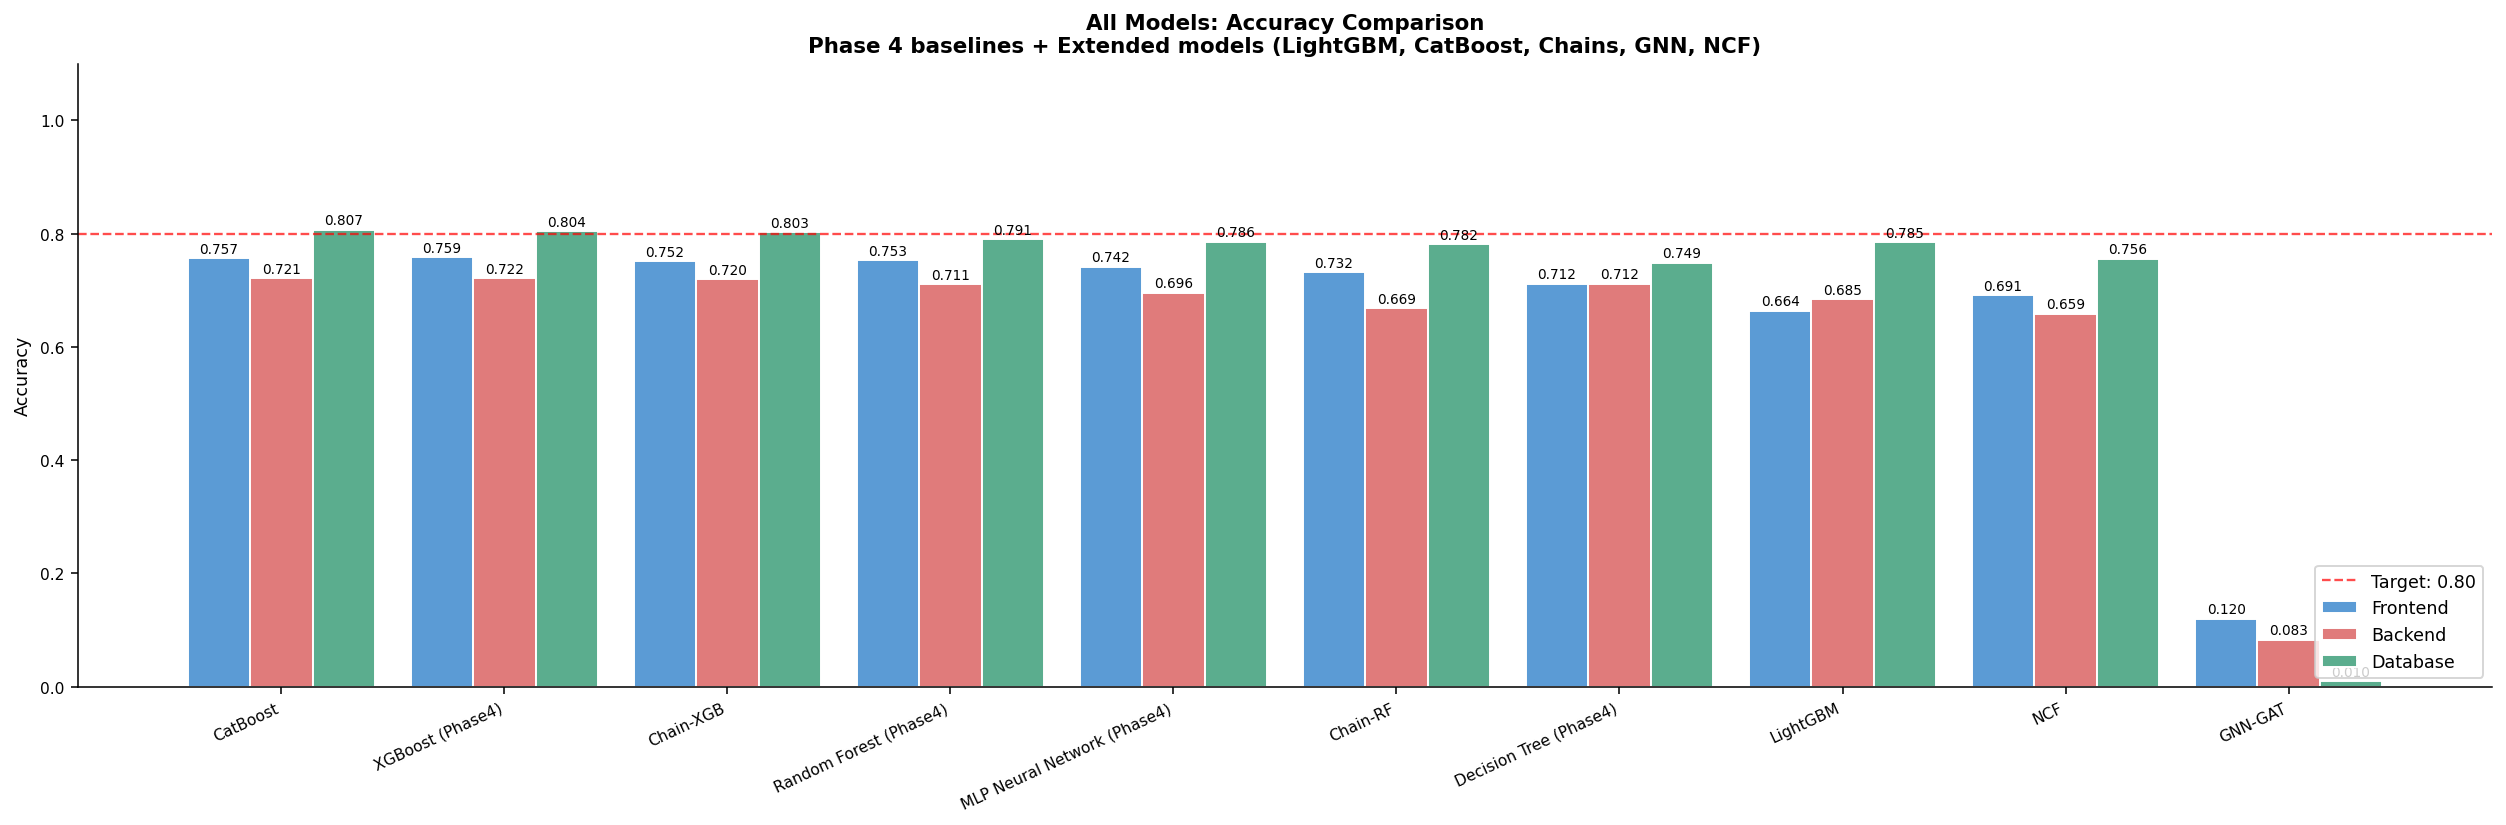

✓ Chart EXT-1 saved → ext_01_all_models_accuracy.png


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 1: Full model comparison (accuracy)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(18, 6))

model_labels = all_df["Model"].tolist()
x = np.arange(len(model_labels))
w = 0.28
C = {"Frontend":"#5B9BD5","Backend":"#E07B7B","Database":"#5BAD8E"}

for ti, tname in enumerate(["Frontend","Backend","Database"]):
    col = tname + " Acc"
    if col in all_df.columns:
        vals = all_df[col].tolist()
    else:
        vals = all_df[f"FE Acc" if tname=="Frontend"
                      else ("BE Acc" if tname=="Backend" else "DB Acc")].tolist()
    bars = ax.bar(x + (ti-1)*w, vals, w, label=tname,
                  color=C[tname], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.004,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(y=0.80, color="red", linestyle="--", linewidth=1.2,
           alpha=0.7, label="Target: 0.80")
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("All Models: Accuracy Comparison\n"
             "Phase 4 baselines + Extended models (LightGBM, CatBoost, Chains, GNN, NCF)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("ext_01_all_models_accuracy.png", bbox_inches="tight")
plt.show()
print("✓ Chart EXT-1 saved → ext_01_all_models_accuracy.png")

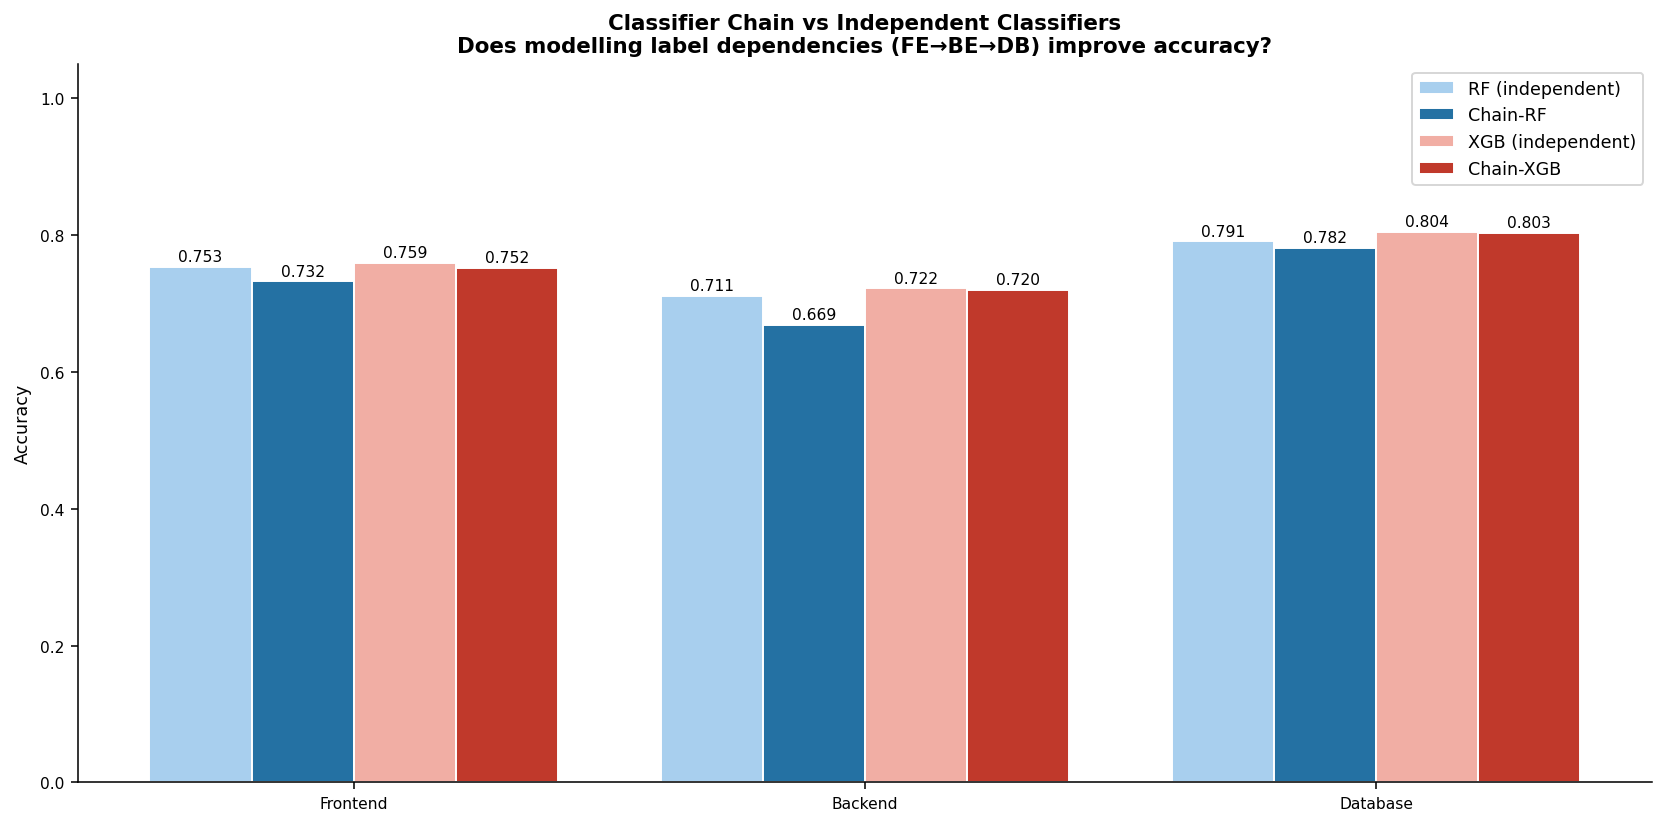

✓ Chart EXT-2 saved → ext_02_chain_vs_independent.png


In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 2: Classifier Chain vs Independent models
# ══════════════════════════════════════════════════════════════
# This chart directly shows whether label dependency modelling helps.
# Compare Chain-RF vs RF (independent) and Chain-XGB vs XGBoost.

chain_compare_data = []
targets_list = ["Frontend","Backend","Database"]

try:
    rf_ind  = baseline_pkl.get("Random Forest", {})
    xgb_ind = baseline_pkl.get("XGBoost", {})
except:
    rf_ind, xgb_ind = {}, {}

models_to_compare = {
    "RF (independent)": {
        t: rf_ind.get(t, {}).get("accuracy", None) for t in targets_list
    } if rf_ind else None,
    "Chain-RF": {
        t: chain_results["Chain-RF"][t]["accuracy"] for t in targets_list
    },
    "XGB (independent)": {
        t: xgb_ind.get(t, {}).get("accuracy", None) for t in targets_list
    } if xgb_ind else None,
    "Chain-XGB": {
        t: chain_results["Chain-XGB"][t]["accuracy"] for t in targets_list
    },
}

x2    = np.arange(len(targets_list))
w2    = 0.20
fig2, ax2 = plt.subplots(figsize=(12, 6))
colours2  = ["#A8CFEE","#2471A3","#F1AEA4","#C0392B"]

for idx, (mname, accs) in enumerate(models_to_compare.items()):
    if accs is None:
        continue
    vals = [accs[t] if accs[t] is not None else 0 for t in targets_list]
    bars = ax2.bar(x2 + (idx-1.5)*w2, vals, w2,
                   label=mname, color=colours2[idx], edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax2.text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.004,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x2)
ax2.set_xticklabels(targets_list)
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05)
ax2.set_title("Classifier Chain vs Independent Classifiers\n"
              "Does modelling label dependencies (FE→BE→DB) improve accuracy?",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig("ext_02_chain_vs_independent.png", bbox_inches="tight")
plt.show()
print("✓ Chart EXT-2 saved → ext_02_chain_vs_independent.png")

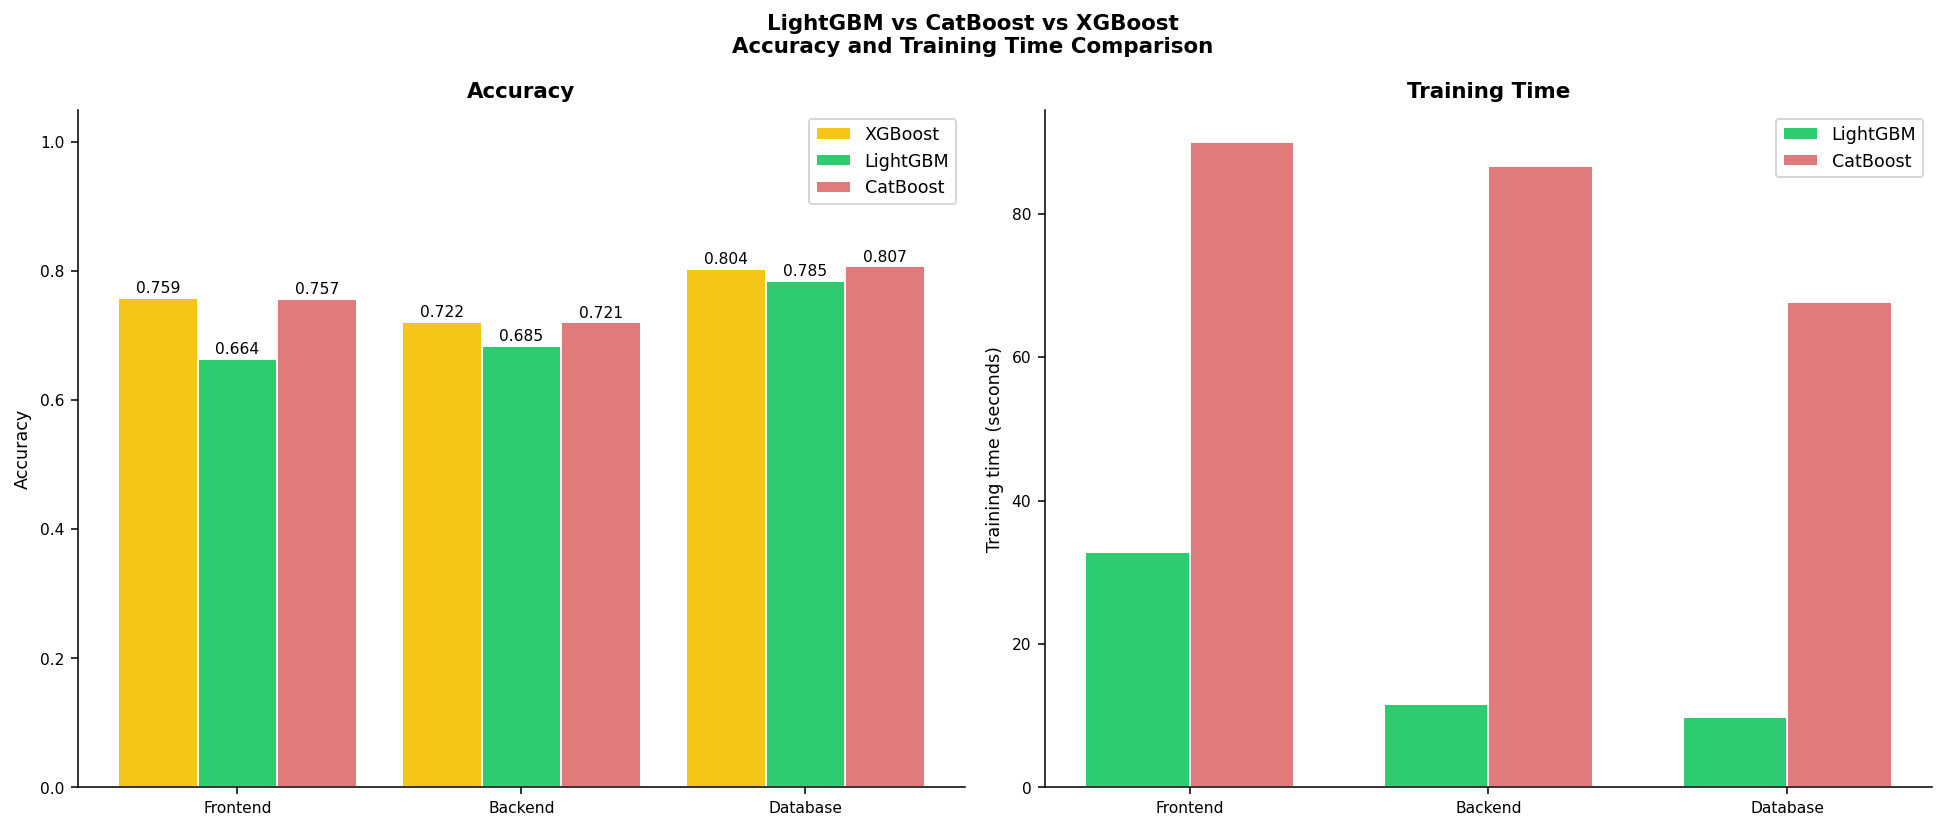

✓ Chart EXT-3 saved → ext_03_lgbm_catboost_xgb.png


In [20]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 3: LightGBM vs CatBoost vs XGBoost
# ══════════════════════════════════════════════════════════════
try:
    xgb_acc = {t: baseline_pkl["XGBoost"][t]["accuracy"] for t in targets_list}
except:
    xgb_acc = None

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle("LightGBM vs CatBoost vs XGBoost\n"
              "Accuracy and Training Time Comparison",
              fontsize=11, fontweight="bold")

# Accuracy subplot
ax_acc = axes3[0]
gbm_models = {"LightGBM": boosting_results["LightGBM"],
              "CatBoost": boosting_results["CatBoost"]}
if xgb_acc:
    gbm_models = {"XGBoost": {t: {"accuracy": xgb_acc[t]} for t in targets_list},
                  **gbm_models}

x3 = np.arange(len(targets_list))
w3 = 0.28
c3 = ["#F5C518","#2ECC71","#E07B7B"]
for idx, (mname, mdict) in enumerate(gbm_models.items()):
    vals = [mdict[t]["accuracy"] if "accuracy" in mdict[t] else mdict[t] for t in targets_list]
    bars = ax_acc.bar(x3 + (idx-1)*w3, vals, w3, label=mname,
                      color=c3[idx], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax_acc.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.003, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=8)
ax_acc.set_xticks(x3)
ax_acc.set_xticklabels(targets_list)
ax_acc.set_ylabel("Accuracy")
ax_acc.set_ylim(0, 1.05)
ax_acc.set_title("Accuracy")
ax_acc.legend(fontsize=9)

# Training time subplot
ax_time = axes3[1]
for idx, (mname, mdict) in enumerate(
    {"LightGBM": boosting_results["LightGBM"],
     "CatBoost": boosting_results["CatBoost"]}.items()
):
    times = [mdict[t]["train_sec"] for t in targets_list]
    ax_time.bar(x3 + (idx-0.5)*0.35, times, 0.35, label=mname,
                color=c3[idx+1], edgecolor="white")

ax_time.set_xticks(x3)
ax_time.set_xticklabels(targets_list)
ax_time.set_ylabel("Training time (seconds)")
ax_time.set_title("Training Time")
ax_time.legend(fontsize=9)

plt.tight_layout()
plt.savefig("ext_03_lgbm_catboost_xgb.png", bbox_inches="tight")
plt.show()
print("✓ Chart EXT-3 saved → ext_03_lgbm_catboost_xgb.png")

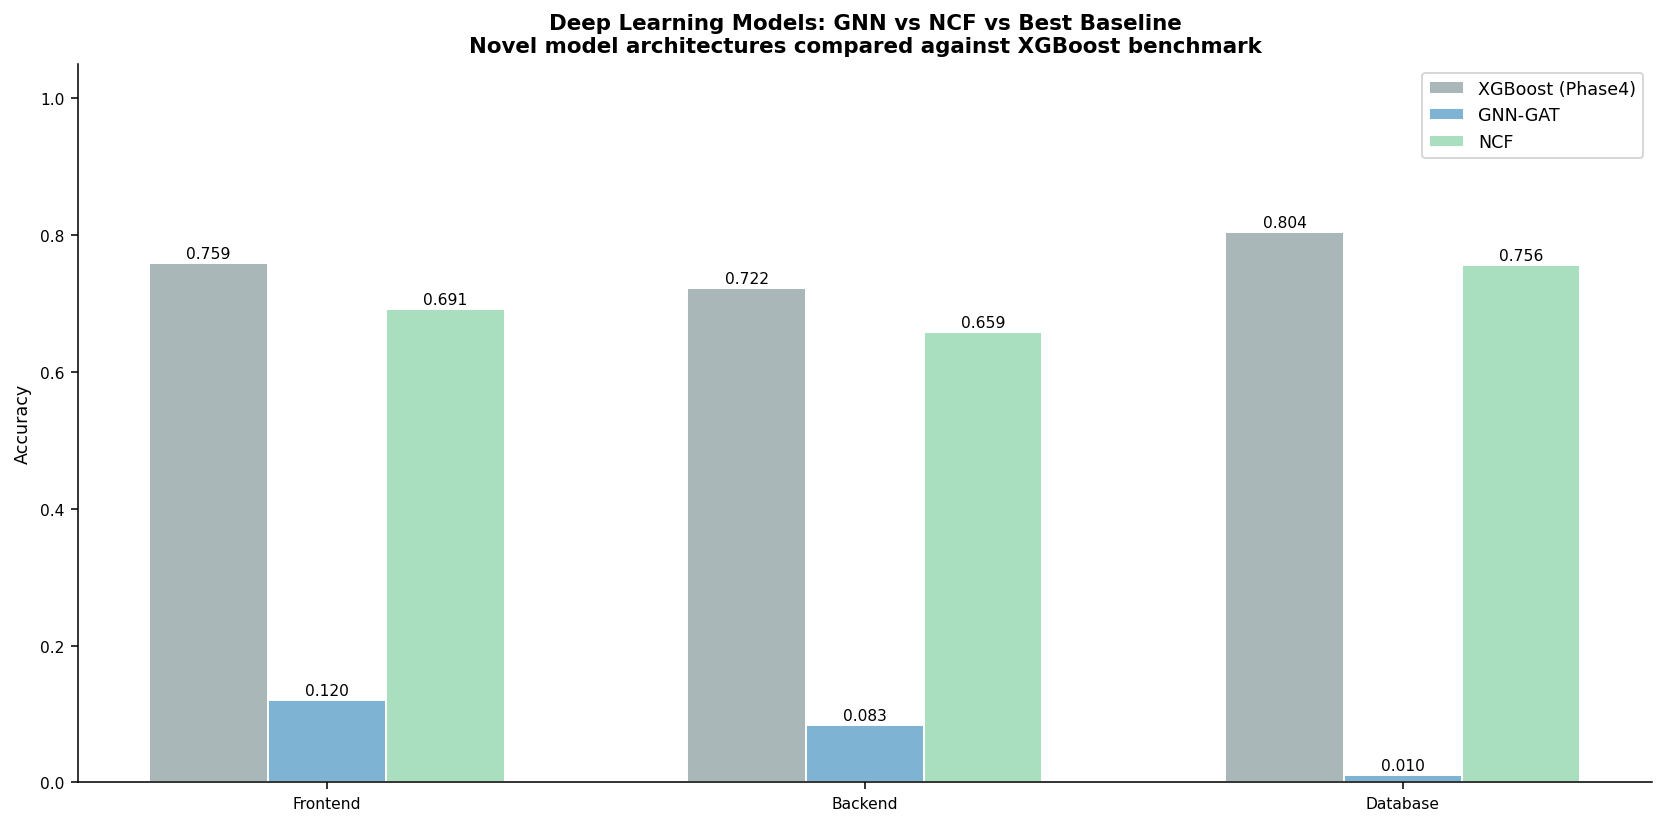

✓ Chart EXT-4 saved → ext_04_gnn_ncf_comparison.png


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 4: GNN & NCF vs best baseline
# ══════════════════════════════════════════════════════════════
try:
    best_baseline_acc = {t: baseline_pkl["XGBoost"][t]["accuracy"] for t in targets_list}
    best_label        = "XGBoost (Phase4)"
except:
    best_baseline_acc = None

fig4, ax4 = plt.subplots(figsize=(12, 6))
x4    = np.arange(len(targets_list))
w4    = 0.22
c4    = ["#AAB7B8","#7FB3D3","#A9DFBF","#F9E79F"]
models_dl = {
    f"GNN-{gnn_label}": {t: gnn_results[t]["accuracy"] for t in targets_list},
    "NCF"              : {t: ncf_results[t]["accuracy"] for t in targets_list},
}
if best_baseline_acc:
    models_dl = {best_label: {t: best_baseline_acc[t] for t in targets_list},
                 **models_dl}

for idx, (mname, accs) in enumerate(models_dl.items()):
    vals = [accs[t] for t in targets_list]
    bars = ax4.bar(x4 + (idx - len(models_dl)/2 + 0.5)*w4,
                   vals, w4, label=mname, color=c4[idx], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax4.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=8)

ax4.set_xticks(x4)
ax4.set_xticklabels(targets_list)
ax4.set_ylabel("Accuracy")
ax4.set_ylim(0, 1.05)
ax4.set_title(f"Deep Learning Models: GNN vs NCF vs Best Baseline\n"
               "Novel model architectures compared against XGBoost benchmark",
              fontsize=11, fontweight="bold")
ax4.legend(fontsize=9)
plt.tight_layout()
plt.savefig("ext_04_gnn_ncf_comparison.png", bbox_inches="tight")
plt.show()
print("✓ Chart EXT-4 saved → ext_04_gnn_ncf_comparison.png")

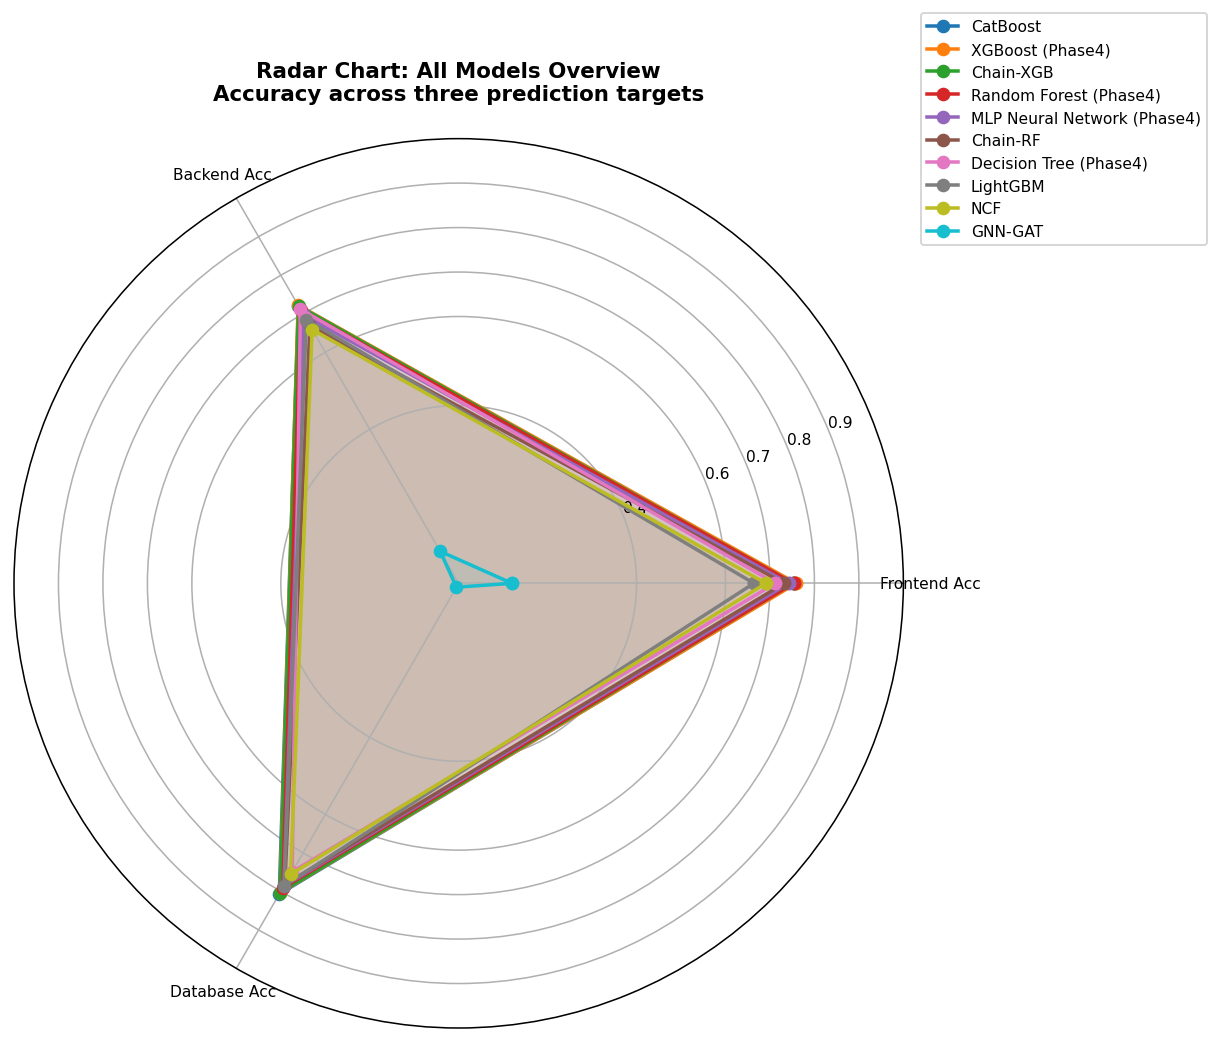

✓ Chart EXT-5 saved → ext_05_radar_all_models.png


In [22]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ CHART 5: Radar / Spider chart — all models overview
# ══════════════════════════════════════════════════════════════
# Radar chart with 3 axes (FE, BE, DB accuracy).
# Gives an at-a-glance view of where each model excels.

from matplotlib.patches import FancyArrowPatch

angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig5, ax5 = plt.subplots(figsize=(9, 9),
                          subplot_kw=dict(polar=True))

radar_models = {r["Model"]: r for _, r in all_df.iterrows()}
colors_radar = plt.cm.tab10(np.linspace(0, 1, len(radar_models)))

for (mname, row), color in zip(radar_models.items(), colors_radar):
    fe = row["FE Acc"]; be = row["BE Acc"]; db = row["DB Acc"]
    values = [fe, be, db, fe]  # close
    ax5.plot(angles, values, "o-", linewidth=1.8, label=mname, color=color)
    ax5.fill(angles, values, alpha=0.07, color=color)

ax5.set_thetagrids(np.degrees(angles[:-1]),
                   ["Frontend Acc","Backend Acc","Database Acc"])
ax5.set_ylim(0, 1.0)
ax5.set_yticks([0.4, 0.6, 0.7, 0.8, 0.9])
ax5.set_yticklabels(["0.4","0.6","0.7","0.8","0.9"], fontsize=8)
ax5.set_title("Radar Chart: All Models Overview\n"
              "Accuracy across three prediction targets",
              fontsize=11, fontweight="bold", pad=20)
ax5.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
           fontsize=8, ncol=1)

plt.tight_layout()
plt.savefig("ext_05_radar_all_models.png", bbox_inches="tight")
plt.show()
print("✓ Chart EXT-5 saved → ext_05_radar_all_models.png")

In [23]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Detailed classification reports (extended models)
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  CLASSIFICATION REPORTS — EXTENDED MODELS")
print("=" * 60)

section_reports = {
    "LightGBM":             boosting_results["LightGBM"],
    "CatBoost":             boosting_results["CatBoost"],
    "Chain-RF":             chain_results["Chain-RF"],
    "Chain-XGB":            chain_results["Chain-XGB"],
    f"GNN-{gnn_label}":     gnn_results,
    "NCF":                  ncf_results,
}

for mname, mres in section_reports.items():
    print(f"\n{'─'*55}\n  {mname.upper()}\n{'─'*55}")
    for tname in ["Frontend","Backend","Database"]:
        r = mres[tname]
        print(f"\n  [{tname}]  acc={r['accuracy']:.3f}  f1_w={r['f1_weighted']:.3f}")
        print(r["report"])


  CLASSIFICATION REPORTS — EXTENDED MODELS

───────────────────────────────────────────────────────
  LIGHTGBM
───────────────────────────────────────────────────────

  [Frontend]  acc=0.664  f1_w=0.662
              precision    recall  f1-score   support

     Angular       0.64      0.83      0.72       107
   Bootstrap       0.22      0.17      0.19        35
     Flutter       1.00      0.78      0.88        23
    HTML/CSS       0.00      0.00      0.00         6
     Next.js       0.40      0.20      0.27        10
       Other       0.00      0.00      0.00         3
       React       0.80      0.77      0.78       584
React Native       0.11      0.11      0.11        61
      Vue.js       0.33      0.39      0.36        36
      jQuery       0.12      0.13      0.12        23

    accuracy                           0.66       888
   macro avg       0.36      0.34      0.34       888
weighted avg       0.66      0.66      0.66       888


  [Backend]  acc=0.685  f1_w=0.687


In [24]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Save all extended results
# ══════════════════════════════════════════════════════════════
extended_pkl = {
    "boosting_results": boosting_results,
    "chain_results":    chain_results,
    "gnn_results":      gnn_results,
    "ncf_results":      ncf_results,
    "summary_df":       all_df,
    "gnn_mode":         gnn_label,
}
joblib.dump(extended_pkl, "extended_results.pkl")
print("✓ extended_results.pkl saved")

# Save PyTorch models separately (joblib doesn't serialise nn.Module well)
torch.save({t: gnn_trained[t].state_dict() for t in gnn_trained},
           "gnn_state_dicts.pt")
torch.save({t: ncf_trained[t].state_dict() for t in ncf_trained},
           "ncf_state_dicts.pt")
print("✓ gnn_state_dicts.pt  saved")
print("✓ ncf_state_dicts.pt  saved")

✓ extended_results.pkl saved
✓ gnn_state_dicts.pt  saved
✓ ncf_state_dicts.pt  saved


In [25]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Final thesis summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  EXTENDED MODEL TRAINING — FINAL SUMMARY")
print("=" * 70)

print(f"\n  {'Model':<28} {'FE Acc':>7} {'BE Acc':>7} "
      f"{'DB Acc':>7} {'Avg Acc':>8}")
print(f"  {'─'*58}")
for _, r in all_df.iterrows():
    marker = " ← best" if _ == all_df.index[0] else ""
    print(f"  {r['Model']:<28} {r['FE Acc']:>7} {r['BE Acc']:>7} "
          f"{r['DB Acc']:>7} {r['Avg Acc']:>8}{marker}")

print(f"\n  Thesis contributions of each new model:")
print(f"  LightGBM   → Faster XGBoost alternative; cite speed advantage")
print(f"  CatBoost   → Ordered boosting; robust baseline; minimal tuning")
print(f"  Chain-RF/XGB → Label dependency modelling; answers RQ on")
print(f"                 whether FE choice influences BE/DB recommendation")
print(f"  GNN-{gnn_label:<10} → Novel: captures tech co-occurrence graph")
print(f"  NCF        → Classic recommender system adapted for stack rec.")
print("=" * 70)


  EXTENDED MODEL TRAINING — FINAL SUMMARY

  Model                         FE Acc  BE Acc  DB Acc  Avg Acc
  ──────────────────────────────────────────────────────────
  CatBoost                       0.757   0.721   0.807    0.762 ← best
  XGBoost (Phase4)               0.759   0.722   0.804    0.762
  Chain-XGB                      0.752    0.72   0.803    0.758
  Random Forest (Phase4)         0.753   0.711   0.791    0.752
  MLP Neural Network (Phase4)    0.742   0.696   0.786    0.741
  Chain-RF                       0.732   0.669   0.782    0.728
  Decision Tree (Phase4)         0.712   0.712   0.749    0.724
  LightGBM                       0.664   0.685   0.785    0.711
  NCF                            0.691   0.659   0.756    0.702
  GNN-GAT                         0.12   0.083    0.01    0.071

  Thesis contributions of each new model:
  LightGBM   → Faster XGBoost alternative; cite speed advantage
  CatBoost   → Ordered boosting; robust baseline; minimal tuning
  Chain-RF/X

In [26]:
# ══════════════════════════════════════════════════════════════
# CELL 17 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "extended_results.pkl",
    "gnn_state_dicts.pt",
    "ncf_state_dicts.pt",
    "extended_model_comparison.csv",
    "ext_01_all_models_accuracy.png",
    "ext_02_chain_vs_independent.png",
    "ext_03_lgbm_catboost_xgb.png",
    "ext_04_gnn_ncf_comparison.png",
    "ext_05_radar_all_models.png",
]

print("\n  Downloading all outputs...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print("\n✓ Extended model training complete.")
print("  Next: compare all_df to Phase 4 baseline results and")
print("  write the model selection section of your thesis.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ extended_results.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ ext_04_gnn_ncf_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ ext_05_radar_all_models.png

✓ Extended model training complete.
  Next: compare all_df to Phase 4 baseline results and
  write the model selection section of your thesis.
